In [1]:
import requests

# pip install beautifulsoup4
from bs4 import BeautifulSoup

# https://www.weather.go.kr/ > 관측기후 > 육상 > 도시별관측
response = requests.get("https://www.weather.go.kr/w/obs-climate/land/city-obs.do")
soup = BeautifulSoup(response.content, 'html.parser')

table = soup.find('table', id='weather_table')

table

data = []
for tr in table.find_all('tr'):
    tds = list(tr.find_all('td'))

    for td in tds:
        if td.find('a'):
            point = td.find('a').text
            temperature = tds[5].text
            humidity = tds[10].text

            data.append([point, temperature, humidity])

data

[['강릉', '0.2', '30'],
 ['강진군', '2.1', '61'],
 ['강화', '-4.6', '52'],
 ['거제', '1.3', '47'],
 ['거창', '-0.1', '50'],
 ['경주시', '0.4', '28'],
 ['고산', '4.1', '71'],
 ['고창', '-1.0', '67'],
 ['고창군', '-1.5', '70'],
 ['고흥', '3.5', '50'],
 ['광양시', '1.9', '46'],
 ['광주', '1.4', '58'],
 ['구미', '0.2', '42'],
 ['군산', '-1.0', '52'],
 ['금산', '-1.7', '54'],
 ['김해시', '0.8', '36'],
 ['남원', '0.6', '49'],
 ['남해', '1.0', '54'],
 ['대관령', '-7.9', '42'],
 ['대구', '0.9', '38'],
 ['대전', '-2.3', '44'],
 ['동두천', '-4.0', '30'],
 ['동해', '0.9', '24'],
 ['목포', '-0.2', '66'],
 ['문경', '-2.3', '41'],
 ['밀양', '1.1', '34'],
 ['백령도', '-2.9', '64'],
 ['보령', '-0.9', '60'],
 ['보성군', '2.2', '57'],
 ['보은', '-2.0', '49'],
 ['봉화', '-1.7', '30'],
 ['부산', '1.4', '33'],
 ['부안', '-1.3', '64'],
 ['부여', '-0.5', '51'],
 ['북강릉', '-0.3', '31'],
 ['북부산', '1.8', '29'],
 ['북창원', '1.3', '40'],
 ['북춘천', '-3.8', '31'],
 ['산청', '1.0', '45'],
 ['상주', '-0.9', '44'],
 ['서귀포', '5.5', '66'],
 ['서산', '-3.4', '54'],
 ['서울', '-2.1', '40'],
 ['서청주', '-3.8', '

In [2]:
with open('weather.csv', 'w', encoding='UTF8') as file:
    file.write('point, temperature, humidity\n')
    for i in data:
        file.write(f'{i[0]},{i[1]},{i[2]}\n')

In [4]:
# matplotlib.pyplot의 show 함수를 호출하지 않아도 주피터 노트북 안에서 그래프가 표시됨
# %matplotlib inline
# pip install pandas
import pandas as pd # 데이터 처리

# csv 파일을 읽어서 DataFrame 객체로 만듦. 인덱스 항목(컬럼)은 point로 설정
# df = pd.read_csv('weather.csv')
df = pd.read_csv('weather.csv', index_col='point')
df



,temperature,humidity
point,,
강릉,0.2,30
강진군,2.1,61
강화,-4.6,52
거제,1.3,47
거창,-0.1,50
...,...,...
합천,1.4,39
해남,1.5,73
홍성,-3.3,51


In [5]:
# 특별시, 광역시만 모아서 DataFrame 객체로 만듦
# loc 속성은 label-location의 약자로 레이블을 지정해 특정 인덱스의 데이터만 가져오는데 씀
city_df = df.loc[['서울', '인천', '대전', '대구', '광주', '부산', '울산']]
city_df

,temperature,humidity
point,,
서울,-2.1,40
인천,-3.8,54
대전,-2.3,44
대구,0.9,38
광주,1.4,58
부산,1.4,33
울산,0.7,25


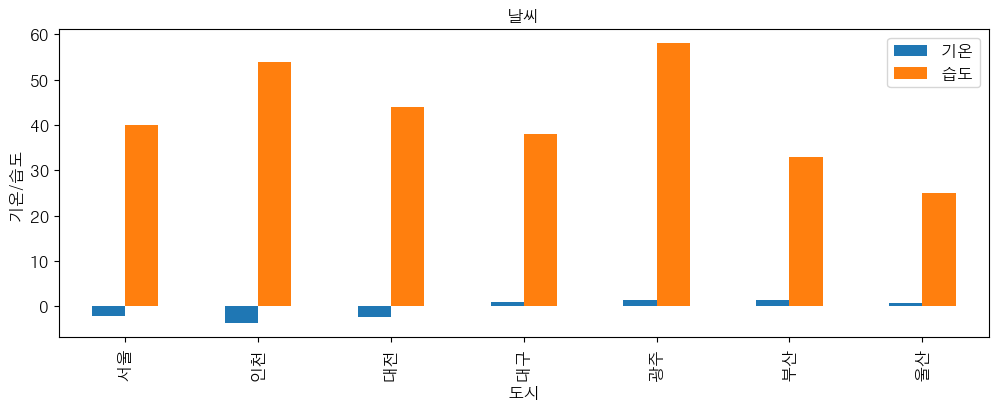

In [7]:
# Windows 한글 폰트 설정해야 함!
# pip install matplotlib
from matplotlib import font_manager, rc

# AttributeError: module 'matplotlib' has no attribute 'font_manager' 에러가 발생하면 해당 코드를 주석 처리한 후 실행한 후, 주석 해제 후 다시 실행하면 됨
# .get_name() 누락 주의!!!
font_path = 'C:/Windows/Fonts/H2GTRM.TTF'
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)

# 차트 종류, 제목, 차트 크기, 범례, 폰트 크기 설정
# ax = city_df.plot() # 이 코드에서 속성을 하나씩 붙여 갈 것!
ax = city_df.plot(kind='bar', title='날씨', figsize=(12, 4), legend=True, fontsize=12)
ax.set_xlabel('도시', fontsize=12)          # x축 정보 표시
ax.set_ylabel('기온/습도', fontsize=12)     # y축 정보 표시
ax.legend(['기온', '습도'], fontsize=12)    # 범례 지정

# import matplotlib.pyplot as plt # IDLE, 파이썬 인터프리터에서 그래프 표시할 경우
# plt.show()